In [1]:
%load_ext autoreload
%autoreload 2

## Quantitative comparison of all datasets

In [ ]:
import yaml
from pathlib import Path as P
from src.experiments_analysis.plots_ismb import model_name_replacement_dict, color_dict

datasets = ["zebrafish_head",
            "mouse_brain",
            "human_lymph_node",
            "mouse_embryo"]

titles_dict = {name.replace("_", " ").capitalize() for name in datasets}

output_dir_dict = {}
output_folder_dict = {}

for dataset in datasets:
    config_path = P("experiments/benchmark_output_files") / f"{dataset}.yaml"
    cfg = yaml.safe_load(open(config_path))
    output_dir_dict[dataset] = cfg["output_dir"]
    main_output_dir = cfg["main_publi_output_folder"]
    output_folder_dict[dataset] = main_output_dir
    P(main_output_dir).mkdir(exist_ok=True, parents=True)

to_plot = [
    "ours",
    "bin-level norm.",
    "original",
    "b2c",
    "b2c-sym",
]

cyto = True
main_panel_path = P("results/publication_oup_v2/figures/panels/panel_quantification_compromise.pdf")
main_panel_path.parent.mkdir(exist_ok=True, parents=True)

global_structure_alteration_label = "Glob. Struct. Alt."

/Users/pmalsot/Documents_no_iCloud/destriping-GLM/src/experiments_analysis/analysis_plots.py:744: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


striping intensity in cytoplasm
striping intensity in cytoplasm
striping intensity in cytoplasm
striping intensity in cytoplasm


/Users/pmalsot/Documents_no_iCloud/destriping-GLM/src/experiments_analysis/analysis_plots.py:635: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/Users/pmalsot/Documents_no_iCloud/destriping-GLM/src/experiments_analysis/analysis_plots.py:635: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/Users/pmalsot/Documents_no_iCloud/destriping-GLM/src/experiments_analysis/analysis_plots.py:635: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/Users/pmalsot/Documents_no_iCloud/destriping-GLM/src/experiments_analysis/analysis_plots.py:635: UserWarning: set_tic

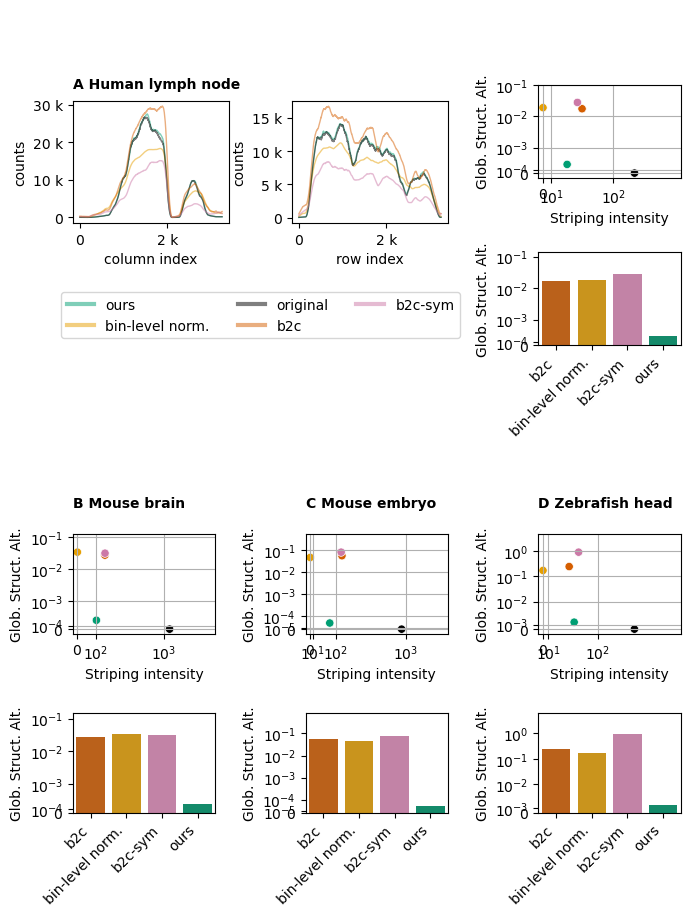

In [5]:
import matplotlib.pyplot as plt
from matplotlib.ticker import EngFormatter

from matplotlib.gridspec import GridSpec
from src.experiments_analysis.analysis_plots import compromise_striping_intensity_global_structure_alteration
from src.experiments_analysis.analysis_plots import (
    barplot_global_structure_alteration,
)
from pathlib import Path as P
from src.experiments_analysis.analysis_plots import global_structure_plot
import matplotlib.pyplot as plt

base_font_size = 10
plt.rcParams.update(
    {
        "font.size": base_font_size,  # base font size
        "axes.labelsize": base_font_size,  # x/y label size
        "axes.titlesize": base_font_size,  # title size
        "xtick.labelsize": base_font_size,  # x tick labels
        "ytick.labelsize": base_font_size,  # y tick labels
        "legend.fontsize": base_font_size,  # legend
    }
)

fontsize_title = 10


# --- Helper to build a (title + 2 plots) panel in one column ---
def make_panel(cell, hspace=1.2):
    sub = cell.subgridspec(3, 1, height_ratios=[0.01, 1.0, 1.0], hspace=hspace)
    ax_title = fig.add_subplot(sub[0, 0])
    ax_top = fig.add_subplot(sub[1, 0])
    ax_bot = fig.add_subplot(sub[2, 0])

    ax_title.axis("off")  # keep it, but NO text inside
    return ax_top, ax_bot, ax_title


axes_compromise_dict = {}
axes_barplot_dict = {}

fig = plt.figure(layout="constrained", figsize=(7.009, 9.27))
gs = GridSpec(4, 3, width_ratios=[1, 1, 1], height_ratios=[1, 1, 1.2, 1], figure=fig)

# --- A: Human lymph node special block (keep your centering approach) ---
gs_hln = gs[0:2, 0:2].subgridspec(
    3, 2, height_ratios=[1.5, 2, 2], wspace=0.4, hspace=0.0
)
ax_hln_col = fig.add_subplot(gs_hln[1, 0])
ax_hln_row = fig.add_subplot(gs_hln[1, 1])

# legend "subplot" occupying the 3rd row across both columns
ax_hln_leg = fig.add_subplot(gs_hln[2, :])
ax_hln_leg.axis("off")  # no frame/ticks

axis = global_structure_plot(
    P(output_dir_dict["human_lymph_node"])
    / "global_structure_analysis",
    P(output_folder_dict["human_lymph_node"]),
    color_dict=color_dict,
    model_name_replacement_dict=model_name_replacement_dict,
    to_plot=to_plot,
    ncol_legend=2,
    axes_not_broken=[ax_hln_col, ax_hln_row],
)


# remove figure-level legends created by the function (if any)
for lg in list(fig.legends):
    lg.remove()

# rebuild legend in the dedicated legend axis
ax_hln_leg.axis("off")

h1, l1 = ax_hln_col.get_legend_handles_labels()
h2, l2 = ax_hln_row.get_legend_handles_labels()

handles, labels = [], []
seen = set()
for h, lab in list(zip(h1, l1)) + list(zip(h2, l2)):
    if lab and lab not in seen:
        handles.append(h)
        labels.append(lab)
        seen.add(lab)

leg = ax_hln_leg.legend(
    handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.0), ncol=3, frameon=True
)
for legline in leg.get_lines():
    legline.set_linewidth(3)

for ax_ in [ax_hln_col, ax_hln_row]:
    ax_.yaxis.set_major_formatter(EngFormatter(unit="", places=0))
    ax_.xaxis.set_major_formatter(EngFormatter(unit="", places=0))

(
    axes_compromise_dict["human_lymph_node"],
    axes_barplot_dict["human_lymph_node"],
    _,
) = make_panel(gs[0:2, 2])


def title_over(ax_title, text, fontsize=13, pad=0.0):
    bb = ax_title.get_position()
    fig.text(
        bb.x0,
        bb.y0 + pad,
        text,
        ha="left",
        va="bottom",
        fontweight="bold",
        fontsize=fontsize,
    )


# B/C/D each occupy rows 2:4 of one column
axes_compromise_dict["mouse_brain"], axes_barplot_dict["mouse_brain"], axB_title = make_panel(gs[2:4, 0])
axes_compromise_dict["mouse_embryo"], axes_barplot_dict["mouse_embryo"], axC_title = make_panel(
    gs[2:4, 1]
)
axes_compromise_dict["zebrafish_head"], axes_barplot_dict["zebrafish_head"], axD_title = make_panel(
    gs[2:4, 2]
)

## Compromise plots

for name in datasets:
    ax = axes_compromise_dict[name]
    ax = compromise_striping_intensity_global_structure_alteration(
        cyto=cyto,
        global_dir_path=P(output_dir_dict[name]) / "global_structure_analysis",
        output_folder=output_folder_dict[name],
        model_name_replacement_dict=model_name_replacement_dict,
        offset_dict=None,
        to_plot=to_plot,
        colors=color_dict,
        ax=ax,
        colors_legend=False,
        annotation=False,
    )
    ax.set_xlabel("Striping intensity")
    ax.set_ylabel(global_structure_alteration_label)


## Barplots

for name in datasets:
    ax = axes_barplot_dict[name]
    axis = barplot_global_structure_alteration(
        P(output_dir_dict[name]) / "global_structure_analysis",
        None,
        model_name_replacement_dict,
        to_plot,
        colors=color_dict,
        ax = ax
    )
    axis.set_ylabel(global_structure_alteration_label)


# A title: you can either keep the fig.text method, or also reserve a title row similarly.
# Quick option (usually enough because top has more room):
# format_axes(fig)
fig.canvas.draw()

pad_title = -0.06

title_over(axB_title, "B Mouse brain", pad=pad_title, fontsize=fontsize_title)
title_over(axC_title, "C Mouse embryo", pad=pad_title, fontsize=fontsize_title)
title_over(axD_title, "D Zebrafish head", pad=pad_title, fontsize=fontsize_title)

# left-aligned above the left A axis (adjust dy if needed)
bb = ax_hln_col.get_position()
fig.text(
    bb.x0,
    bb.y1 + 0.01,
    "A Human lymph node",
    ha="left",
    va="bottom",
    fontweight="bold",
    fontsize=fontsize_title,
)

plt.savefig(main_panel_path)
plt.show()